In [515]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
import statsmodels.api as sm
from datetime import datetime
import matplotlib.patches as patches

In [516]:
# #DATA FROM 2017-2025
# crime = pd.read_csv("rms_crime_incidents.csv", comment='#')

# crime.head()


C:\Users\enora\AppData\Local\Temp\ipykernel_16852\1558106112.py:2: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  crime = pd.read_csv("rms_crime_incidents.csv", comment='#')


,X,Y,incident_entry_id,nearest_intersection,offense_category,offense_description,state_offense_code,arrest_charge,charge_description,incident_occurred_at,...,report_number,scout_car_area,police_precinct,census_block_2020_geoid,neighborhood,council_district,zip_code,longitude,latitude,ESRI_OID
0,-83.241300,42.374040,1255424-2307,Wadsworth St & Fielding St,LARCENY,LARCENY - OTHER ...,2307,23007,LARCENY - OTHER ...,2025/03/11 04:00:00+00,...,2503170044,0603,06,2.616355e+14,Weatherby,7.0,48228.0,-83.241300,42.374040,1.0
1,-83.147703,42.340357,1380965-2601,McDonald St & Radcliffe St,FRAUD,FRAUD - FALSE PRETENSE / SWINDLE / CONFIDENCE ...,2601,26001,FRAUD - FALSE PRETENSE / SWINDLE / CONFIDENCE ...,2025/12/17 17:30:00+00,...,2601020174,0401,04,2.616353e+14,Claytown,6.0,48210.0,-83.147703,42.340357,2.0
2,-83.114223,42.357153,1389365-2900,Seebaldt St & Turner St,DAMAGE TO PROPERTY,DAMAGE TO PROPERTY ...,2900,29000,DAMAGE TO PROPERTY ...,2026/01/27 12:06:00+00,...,2601270059,1006,10,2.616353e+14,Midwest,6.0,48204.0,-83.114223,42.357153,3.0
3,-83.043401,42.424733,1363733-5701,Iowa St & Minnesota St,INVASION OF PRIVACY -OTHER,TRESPASS,5701,57001,TRESPASS,2025/11/17 01:24:00+00,...,2511160321,1108,11,2.616351e+14,Davison,3.0,48212.0,-83.043401,42.424733,4.0
4,-83.043401,42.424733,1363732-1301,Iowa St & Minnesota St,ASSAULT,ASSAULT AND BATTERY/SIMPLE ASSAULT,1301,13001,ASSAULT AND BATTERY/SIMPLE ASSAULT,2025/11/17 01:24:00+00,...,2511160321,1108,11,2.616351e+14,Davison,3.0,48212.0,-83.043401,42.424733,5.0


In [517]:
# #crime["date"] = pd.to_datetime(crime["date"], utc=True)
# #list(crime.columns)
# crime['incident_occurred_at'].head()

# crime["date"] = pd.to_datetime(
#     crime["incident_occurred_at"],
#     utc=True
# )

# crime_ts = crime[
#     (crime["incident_occurred_at"] >= "2017-01-01") &
#     (crime["incident_occurred_at"] <  "2026-01-01")
# ]


# monthly_counts = (
#     crime_ts
#     .set_index("date")
#     .resample("MS")         # Month Start
#     .size()
#     .rename("crime_count")
#     .reset_index()
# )

# print("Monthly points:", len(monthly_counts))

Monthly points: 108


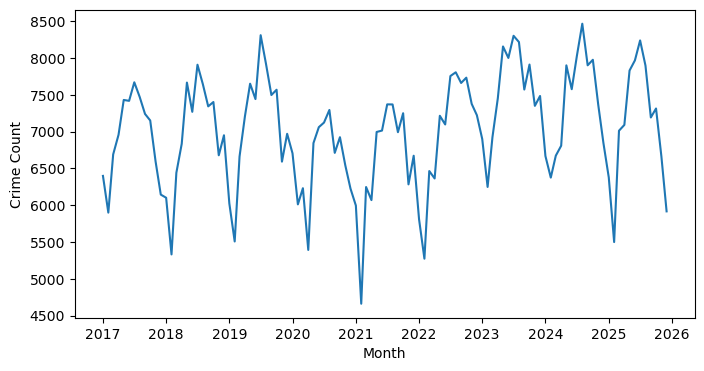

In [518]:
# plt.figure(figsize=(8, 4))
# plt.plot(monthly_counts['date'], monthly_counts['crime_count'])
# plt.xlabel('Month'); plt.ylabel('Crime Count'); plt.show()

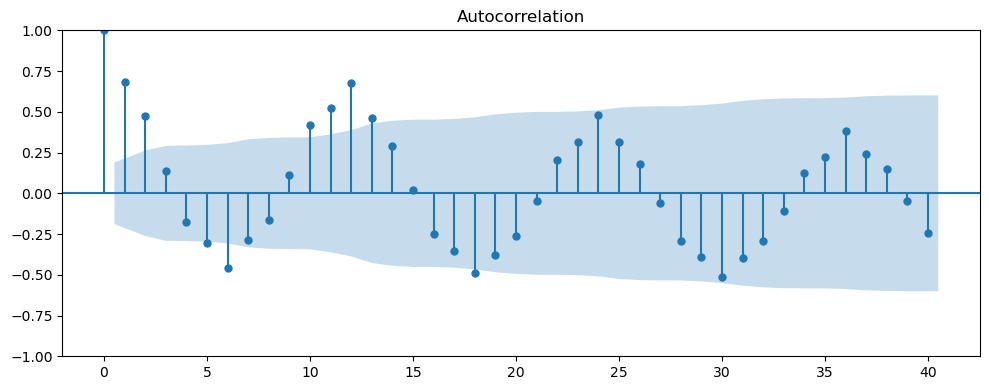

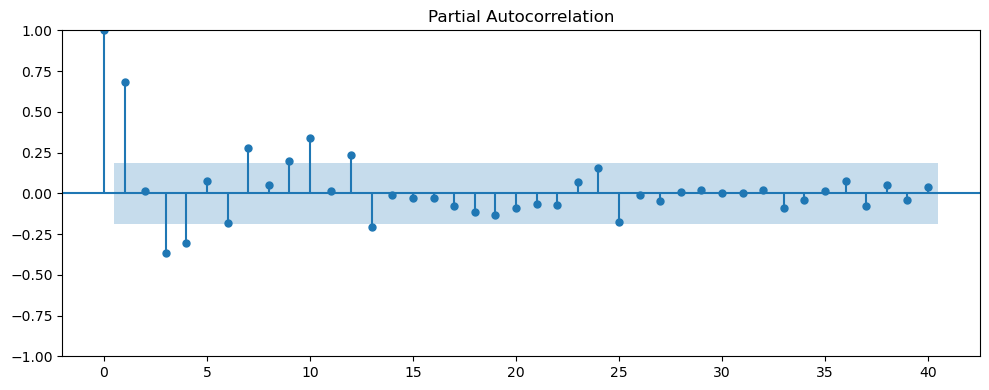

In [519]:
# fig, ax = plt.subplots(figsize=(10, 4))
# plot_acf(monthly_counts['crime_count'], ax=ax, lags=40)
# plt.tight_layout()
# plt.show()

# fig, ax = plt.subplots(figsize=(10, 4))
# plot_pacf(monthly_counts['crime_count'], ax=ax, lags=40)
# plt.tight_layout()
# plt.show()

In [520]:
# #creating a covid indicator var
# #0 pre covid, 1 during covid, 2 post covid

# monthly_counts["covid"] = np.select(
#     [
#         monthly_counts["date"] < pd.Timestamp("2020-03-01", tz="UTC"),
#         (monthly_counts["date"] >= pd.Timestamp("2020-03-01", tz="UTC")) & (monthly_counts["date"] < pd.Timestamp("2022-07-01", tz="UTC")),
#         monthly_counts["date"] >= pd.Timestamp("2022-07-01", tz="UTC"),
#     ],
#     ["pre", "during", "post"],
#     default="unknown" 
# )



# monthly_counts["covid"] = pd.Categorical(
#     monthly_counts["covid"],
#     categories=["pre", "during", "post"],
#     ordered=True
# )



In [521]:
# X = pd.get_dummies(monthly_counts["covid"], drop_first=True).astype(float)

In [522]:
# #NOW LOOKING AT UNEMPLOYMENT DATA
# unemploy = pd.read_csv("unemployment_wayne_county.csv")
# print(unemploy.head())

# unemploy = unemploy[unemploy['Year'] >= 2016]

# unemploy["date"] = pd.to_datetime(unemploy["Label"], format="%Y %b")

# unemploy_ts = unemploy.loc[
#     (unemploy['date'] >= '2017-01-01') & 
#     (unemploy['date'] < '2026-01-01')
# ].copy()

# unemploy_ts["Value"] = pd.to_numeric(unemploy_ts["Value"], errors="coerce")

# monthly_unemploy = (
#     unemploy_ts
#     .set_index("date")['Value']
#     .resample("MS")
#     .mean()
#     .rename("unemploy_rate")
#     .reset_index()
# )

              Series ID  Year Period     Label Value
0  LAUCN261630000000003  2010    M01  2010 Jan  17.1
1  LAUCN261630000000003  2010    M02  2010 Feb  16.8
2  LAUCN261630000000003  2010    M03  2010 Mar  16.9
3  LAUCN261630000000003  2010    M04  2010 Apr  16.0
4  LAUCN261630000000003  2010    M05  2010 May  15.6


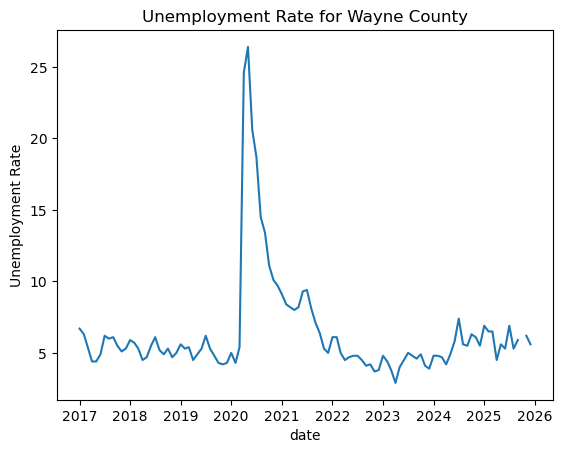

In [523]:
# plt.plot(monthly_unemploy["date"], monthly_unemploy["unemploy_rate"])
# plt.xlabel("date")
# plt.ylabel("Unemployment Rate")
# plt.title("Unemployment Rate for Wayne County")

# plt.show()

In [524]:
# monthly_unemploy.loc[monthly_unemploy["unemploy_rate"].isna(), ["unemploy_rate"]]
# #missing data for Oct 2025 
# print(monthly_unemploy.at[105, 'date'])

# #imputing by taking average of Sept and Nov 2025
# monthly_unemploy.at[105, "unemploy_rate"] = (monthly_unemploy.at[104, "unemploy_rate"] + monthly_unemploy.at[106, "unemploy_rate"]) / 2
# print(monthly_unemploy.at[105, "unemploy_rate"])

2025-10-01 00:00:00
6.050000000000001


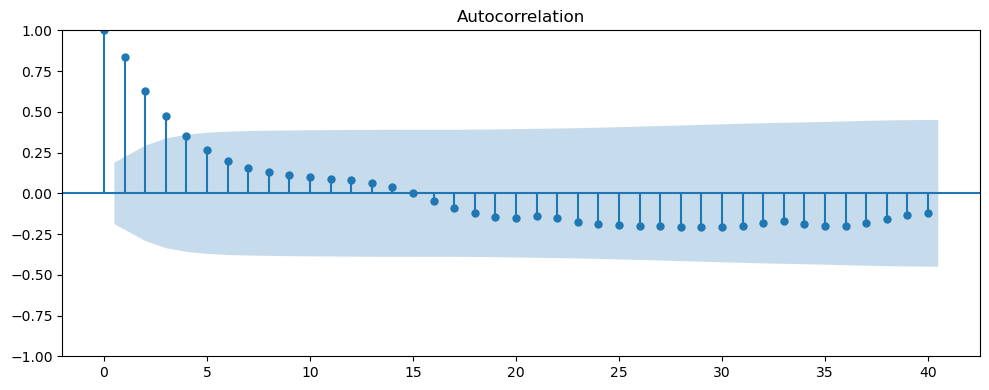

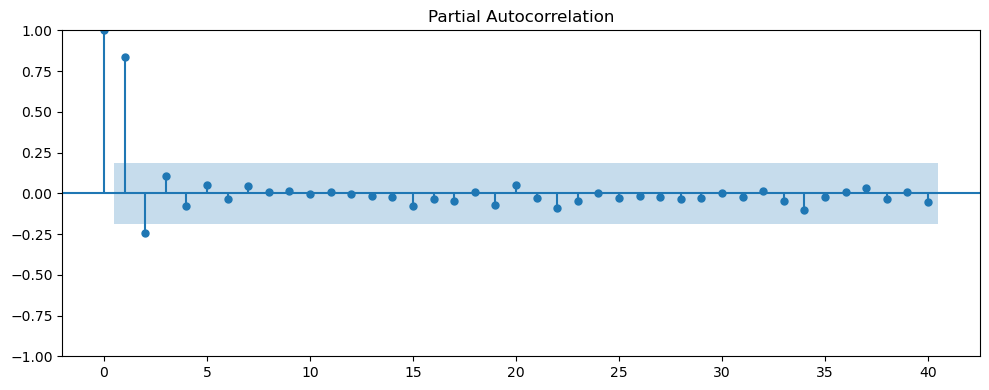

In [525]:
# fig, ax = plt.subplots(figsize=(10, 4))
# plot_acf(monthly_unemploy["unemploy_rate"], ax=ax, lags=40)
# plt.tight_layout()
# plt.show()

# fig, ax = plt.subplots(figsize=(10, 4))
# plot_pacf(monthly_unemploy["unemploy_rate"], ax=ax, lags=40)
# plt.tight_layout()
# plt.show()

In [526]:
# mc = monthly_counts.copy()
# mc.index = pd.date_range("2017-01-01", periods=len(mc), freq="MS") 

In [527]:
# #CREATING EXOGENOUS VARIABLE MATRIX
# # ----- y with real dates -----
# y = mc["crime_count"].rename("y")
# y.index = y.index.to_period("M").to_timestamp(how="start")
# idx_m = y.index.to_period("M")

# # ----- dummies -----
# X_arr = np.asarray(X)
# X_df = pd.DataFrame(X_arr[:, :2], index=idx_m, columns=["during","post"])

# # ----- unemployment (already date-indexed) -----
# u = monthly_unemploy["unemploy_rate"].copy()
# #u.index = pd.DatetimeIndex(u.index).to_period("M")
# #u = u.reindex(idx_m)
# #u = monthly_unemploy["unemploy_rate"].copy()
# u = pd.Series(u.to_numpy(), index=idx_m, name="unemploy_rate")

# # ----- exog -----
# exog_data = pd.concat([X_df, u.rename("unemploy_rate")], axis=1)
# exog_dt = exog_data.copy()
# exog_dt.index = exog_dt.index.to_timestamp(how="start")


# print(exog_data.isna().sum())         # should be all zeros now
# print(exog_dt.index.equals(y.index))  # should be True

# exog_base = exog_dt.copy()

# t = np.arange(len(exog_base), dtype=float)
# t = (t - t.mean()) / t.std()   # optional but recommended

# exog_slope = exog_base.copy()
# exog_slope["t"] = t
# exog_slope["t_during"] = t * exog_slope["during"]

# # ----- df0 (aligned master frame) -----
# df0 = pd.concat([y, exog_dt], axis=1).dropna()
# y_aligned = df0["y"]
# X_aligned = df0.drop(columns="y")

during           0
post             0
unemploy_rate    0
dtype: int64
True


In [528]:
# y_aligned = df0["y"]
# exog_aligned = df0.drop(columns="y")

In [529]:
# print(y_aligned.head())
# print(exog_aligned.head())

2017-01-01    6399
2017-02-01    5900
2017-03-01    6691
2017-04-01    6958
2017-05-01    7431
Freq: MS, Name: y, dtype: int64
            during  post  unemploy_rate
2017-01-01     0.0   0.0            6.7
2017-02-01     0.0   0.0            6.3
2017-03-01     0.0   0.0            5.4
2017-04-01     0.0   0.0            4.4
2017-05-01     0.0   0.0            4.4


In [530]:
# #MODEL SELECTION FUNCTION
# def sarimax_aic_table(data, p_max, q_max, P_max, Q_max, m): # D = 1
#     results = []
#     # parallelize
#     # Iterate through all combinations
#     for p in range(p_max + 1):
#         for q in range(q_max + 1):
#             for P in range(P_max + 1):
#                 for Q in range(Q_max + 1):
#                     try:
#                         model = SARIMAX(data, order=(p,0,q), trend='n',
#                         seasonal_order=(P, 0, Q, m), exog=exog_aligned)
#                         results_fit = model.fit(disp=False)
#                         results.append([p, q, P, Q, results_fit.aic])
#                     except:
#                         results.append([p, q, P, Q, np.nan])
                        
#     # Create DataFrame
#     df = pd.DataFrame(results, columns=['AR(p)', 'MA(q)', 'SAR(P)', 'SMA(Q)', 'AIC'])
#     df.sort_values(by='AIC')
#     # Sort by AIC ascending
#     return df.sort_values(by='AIC')

# sarimax_results = sarimax_aic_table(y_aligned, 2, 1, 1, 1, 12)

C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximu

In [531]:
# sarimax_results

,AR(p),MA(q),SAR(P),SMA(Q),AIC
17,2,0,0,1,14.000000
10,1,0,1,0,1692.883483
8,1,0,0,0,1697.372870
14,1,1,1,0,1703.502846
20,2,1,0,0,1704.167178
22,2,1,1,0,1709.370870
16,2,0,0,0,1710.680288
9,1,0,0,1,1717.528944
13,1,1,0,1,1720.059225
21,2,1,0,1,1729.814024


In [532]:
# new_mod = SARIMAX(
#     y_aligned,
#     exog=X_aligned,
#     order=(1,0,0),
#     seasonal_order=(1,0,0,12),
#     trend="c"
# ).fit(disp=False)

# print(new_mod.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  108
Model:             SARIMAX(1, 0, 0)x(1, 0, 0, 12)   Log Likelihood                -841.975
Date:                            Tue, 17 Feb 2026   AIC                           1697.950
Time:                                    10:13:14   BIC                           1716.725
Sample:                                01-01-2017   HQIC                          1705.563
                                     - 12-01-2025                                         
Covariance Type:                              opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
intercept       213.3324    162.586      1.312      0.189    -105.330     531.995
during         -149.2875  

C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


AR roots: [1.08914465]


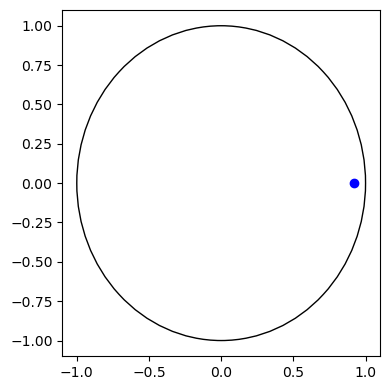

In [533]:
# #NON SEASONAL ROOTS
# ar_pars = new_mod.arparams 
# ar_poly = np.polynomial.Polynomial(np.r_[1,-ar_pars]) 
# print(f"AR roots: {ar_poly.roots()}")
# inv_ar_roots = 1/ar_poly.roots()

# fig, ax = plt.subplots(figsize=(4, 4))
# unit_circle1 = patches.Circle((0, 0), radius=1, edgecolor='black', facecolor='None')
# ax.add_patch(unit_circle1)
# ax.scatter(np.real(inv_ar_roots), np.imag(inv_ar_roots), color='blue', marker='o', label="Inverse AR Roots")

# plt.tight_layout()
# plt.show()

Seasonal AR roots: [-1.05844912e+00+0.j         -9.16643829e-01+0.52922456j
 -9.16643829e-01-0.52922456j -5.29224562e-01+0.91664383j
 -5.29224562e-01-0.91664383j  4.15160396e-16+1.05844912j
  4.15160396e-16-1.05844912j  5.29224562e-01+0.91664383j
  5.29224562e-01-0.91664383j  1.05844912e+00+0.j
  9.16643829e-01+0.52922456j  9.16643829e-01-0.52922456j]


C:\Users\enora\AppData\Local\Temp\ipykernel_16852\1717699080.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  phi_S12 = new_mod.params[new_mod.param_names.index("ar.S.L12")]


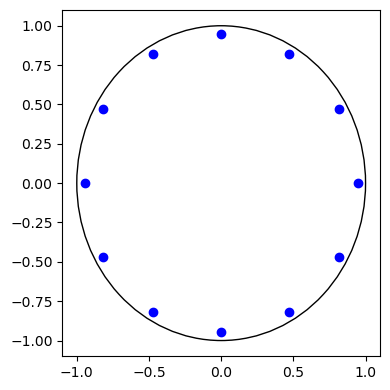

In [534]:
# #SEASONAL ROOTS
# phi_S12 = new_mod.params[new_mod.param_names.index("ar.S.L12")]
# s = 12

# # Build seasonal AR polynomial: 1 - phi * L^12
# sar_poly = np.zeros(s + 1)
# sar_poly[0] = 1.0
# sar_poly[s] = -phi_S12

# # Roots and inverse roots
# sar_roots = np.roots(sar_poly[::-1])
# inv_sar_roots = 1 / sar_roots

# print(f"Seasonal AR roots: {sar_roots}")

# fig, ax = plt.subplots(figsize=(4, 4))
# unit_circle1 = patches.Circle((0, 0), radius=1, edgecolor='black', facecolor='None')
# ax.add_patch(unit_circle1)
# ax.scatter(np.real(inv_sar_roots), np.imag(inv_sar_roots), color='blue', marker='o', label="Inverse AR Roots")

# plt.tight_layout()
# plt.show()

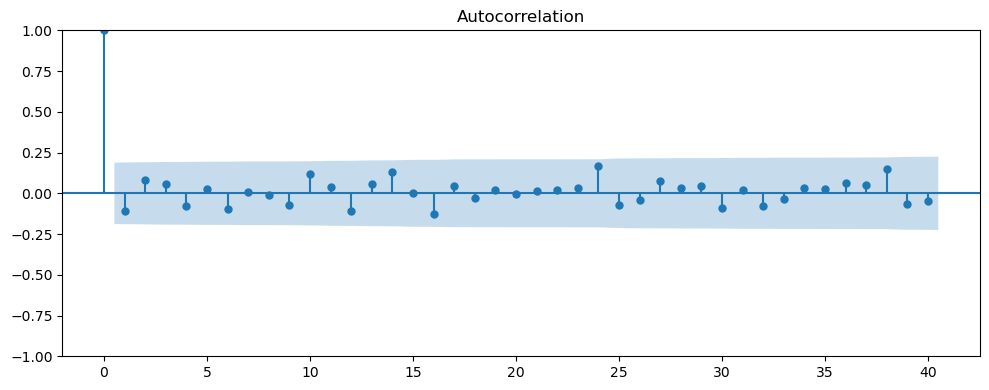

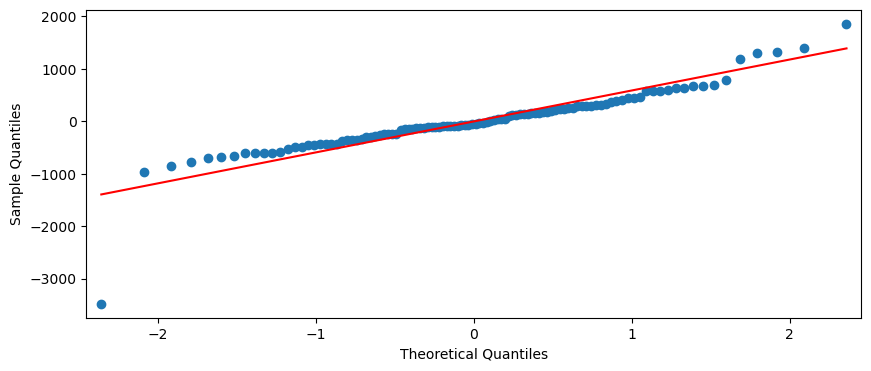

In [535]:
# #RESIDUAL CHECKS- ACF PLOT AND QQ PLOT
# new_resids = new_mod.resid

# fig, ax = plt.subplots(figsize=(10, 4))
# plot_acf(new_resids, ax=ax, lags=40)
# plt.tight_layout()
# plt.show()

# fig, ax = plt.subplots(figsize=(10, 4))
# sm.qqplot(new_resids, line='s', ax=ax)
# plt.show()

In [536]:
# #TRYING TO FIT LOG OF CRIME COUNTS TO IMRPOVE RESIDUAL NORMALITY
# new_mod_log = SARIMAX(
#     np.log(y_aligned),
#     exog=X_aligned,
#     order=(1,0,0),
#     seasonal_order=(1,0,0,12),
#     trend="c"
# ).fit(disp=False)

# print(new_mod_log.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  108
Model:             SARIMAX(1, 0, 0)x(1, 0, 0, 12)   Log Likelihood                 144.454
Date:                            Tue, 17 Feb 2026   AIC                           -274.907
Time:                                    10:13:15   BIC                           -256.133
Sample:                                01-01-2017   HQIC                          -267.295
                                     - 12-01-2025                                         
Covariance Type:                              opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
intercept         0.0748      0.091      0.822      0.411      -0.103       0.253
during           -0.1859  

C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


AR roots: [1.03486157]


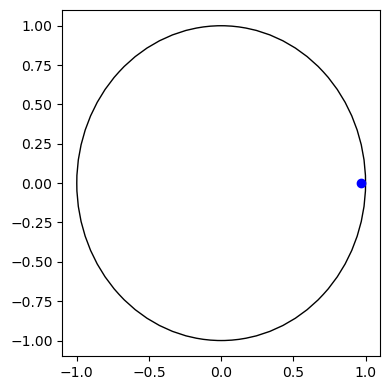

In [537]:
# #NON SEASONAL ROOTS
# ar_pars = new_mod_log.arparams 
# ar_poly = np.polynomial.Polynomial(np.r_[1,-ar_pars]) 
# print(f"AR roots: {ar_poly.roots()}")
# inv_ar_roots = 1/ar_poly.roots()

# fig, ax = plt.subplots(figsize=(4, 4))
# unit_circle1 = patches.Circle((0, 0), radius=1, edgecolor='black', facecolor='None')
# ax.add_patch(unit_circle1)
# ax.scatter(np.real(inv_ar_roots), np.imag(inv_ar_roots), color='blue', marker='o', label="Inverse AR Roots")

# plt.tight_layout()
# plt.show()

Seasonal AR roots: [-1.02414547e+00+0.j         -8.86935991e-01+0.51207273j
 -8.86935991e-01-0.51207273j -5.12072733e-01+0.88693599j
 -5.12072733e-01-0.88693599j -3.66938220e-16+1.02414547j
 -3.66938220e-16-1.02414547j  5.12072733e-01+0.88693599j
  5.12072733e-01-0.88693599j  1.02414547e+00+0.j
  8.86935991e-01+0.51207273j  8.86935991e-01-0.51207273j]


C:\Users\enora\AppData\Local\Temp\ipykernel_16852\2462233871.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  phi_S12 = new_mod_log.params[new_mod.param_names.index("ar.S.L12")]


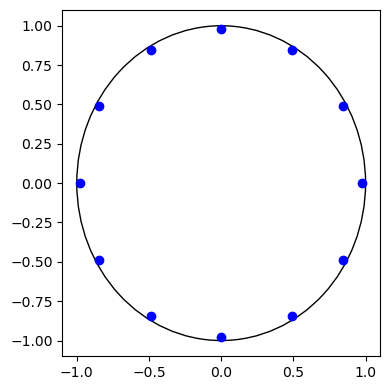

In [538]:
# #SEASONAL ROOTS
# phi_S12 = new_mod_log.params[new_mod.param_names.index("ar.S.L12")]
# s = 12

# # Build seasonal AR polynomial: 1 - phi * L^12
# sar_poly = np.zeros(s + 1)
# sar_poly[0] = 1.0
# sar_poly[s] = -phi_S12

# # Roots and inverse roots
# sar_roots = np.roots(sar_poly[::-1])
# inv_sar_roots = 1 / sar_roots

# print(f"Seasonal AR roots: {sar_roots}")

# fig, ax = plt.subplots(figsize=(4, 4))
# unit_circle1 = patches.Circle((0, 0), radius=1, edgecolor='black', facecolor='None')
# ax.add_patch(unit_circle1)
# ax.scatter(np.real(inv_sar_roots), np.imag(inv_sar_roots), color='blue', marker='o', label="Inverse AR Roots")

# plt.tight_layout()
# plt.show()

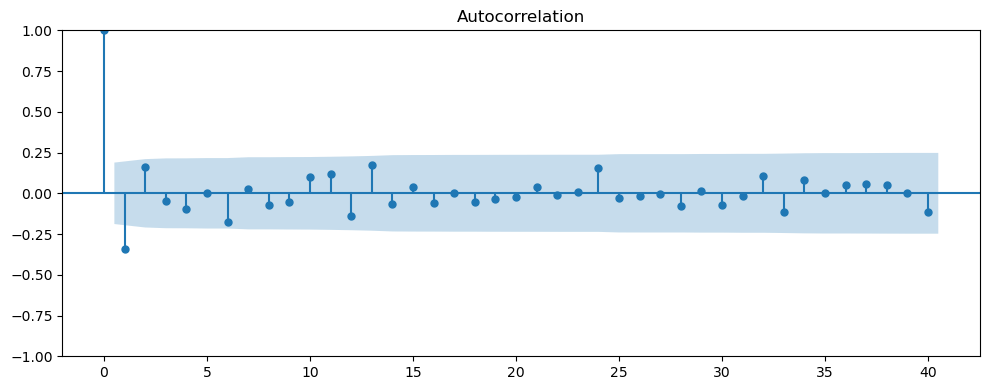

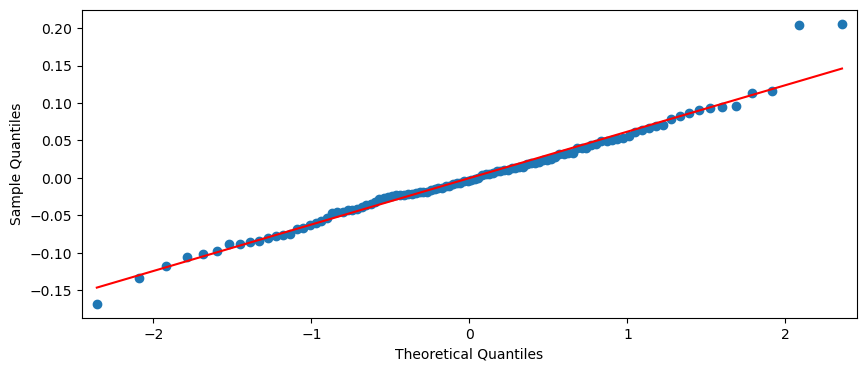

In [539]:
# #RESIDUAL CHECKS- ACF PLOT AND QQ PLOT
# new_resids_log = new_mod_log.resid

# fig, ax = plt.subplots(figsize=(10, 4))
# plot_acf(new_resids_log, ax=ax, lags=40)
# plt.tight_layout()
# plt.show()

# fig, ax = plt.subplots(figsize=(10, 4))
# sm.qqplot(new_resids_log, line='s', ax=ax)
# plt.show()

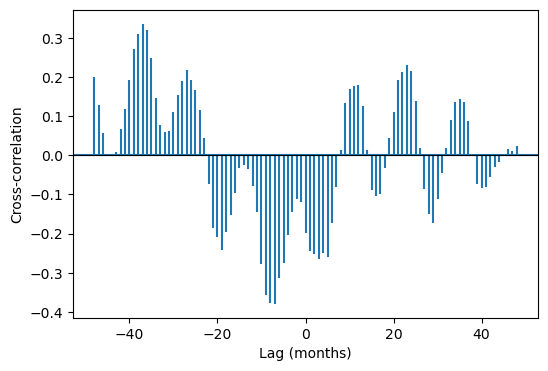

In [540]:
# #CROSS CORRELATION
# x = monthly_counts["crime_count"] - monthly_counts["crime_count"].mean()
# y = monthly_unemploy["unemploy_rate"] - monthly_unemploy["unemploy_rate"].mean()

# plt.figure(figsize=(6, 4))
# plt.xcorr(y, x, maxlags=48, normed=True)

# plt.axhline(0, color="black", linewidth=0.8)
# plt.xlabel("Lag (months)")
# plt.ylabel("Cross-correlation")
# plt.show()

In [541]:
#DATA SPANNING 1990-2025

unem_new = pd.read_csv("Monthly_Unemployment_Data.csv",  comment='#')
crime_new = pd.read_csv("Monthly_Crime_Data.csv",  comment='#')

print(crime_new.head())
print(unem_new.head())

   Unnamed: 0        Date  Property_Crime  Violent_Crime
0          60  1990-01-01            8829           2385
1          61  1990-02-01            6991           1903
2          62  1990-03-01            7860           2116
3          63  1990-04-01            7648           2105
4          64  1990-05-01            7281           2387
   Unnamed: 0             Series ID  Year Period     Label  Value        Date
0           0  LAUCN261630000000003  1990    M01  1990 Jan    9.1  1990-01-01
1           1  LAUCN261630000000003  1990    M02  1990 Feb    9.2  1990-02-01
2           2  LAUCN261630000000003  1990    M03  1990 Mar    8.9  1990-03-01
3           3  LAUCN261630000000003  1990    M04  1990 Apr    8.4  1990-04-01
4           4  LAUCN261630000000003  1990    M05  1990 May    8.6  1990-05-01


In [542]:
unem_new.loc[unem_new["Value"].isna(), ["Value"]]
#doesnt appear to be any missing values??

,Value


In [543]:
#crime["date"] = pd.to_datetime(crime["date"], utc=True)
#list(crime.columns)
crime_new['Date'].head()

crime_new["Date"] = pd.to_datetime(
    crime_new["Date"],
    utc=True
)

crime_new["total"] = (
    crime_new["Property_Crime"] + crime_new["Violent_Crime"]
)

crime_ts_new = crime_new[
    (crime_new["Date"] >= "1990-01-01") &
    (crime_new["Date"] <  "2026-01-01")
]


monthly_counts_new = (
    crime_ts_new
    .set_index("Date")["total"]
    .resample("MS")
    .sum()
    .rename("total")
    .reset_index()
)

print("Monthly points:", len(monthly_counts_new))

print(monthly_counts_new.head())

Monthly points: 432
                       Date  total
0 1990-01-01 00:00:00+00:00  11214
1 1990-02-01 00:00:00+00:00   8894
2 1990-03-01 00:00:00+00:00   9976
3 1990-04-01 00:00:00+00:00   9753
4 1990-05-01 00:00:00+00:00   9668


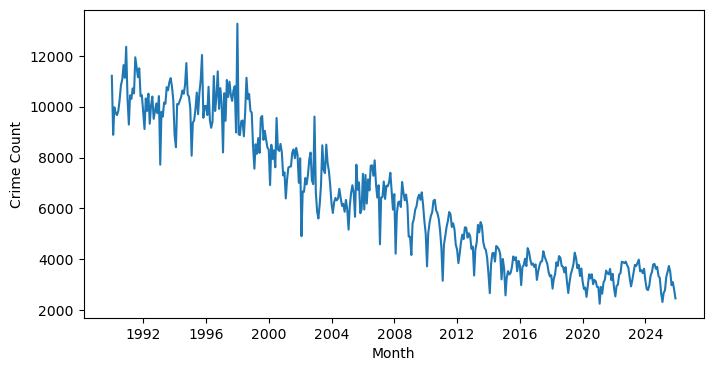

In [832]:
plt.figure(figsize=(8, 4))
plt.plot(monthly_counts_new['Date'], monthly_counts_new['total'])
plt.xlabel('Month'); plt.ylabel('Crime Count'); plt.show()

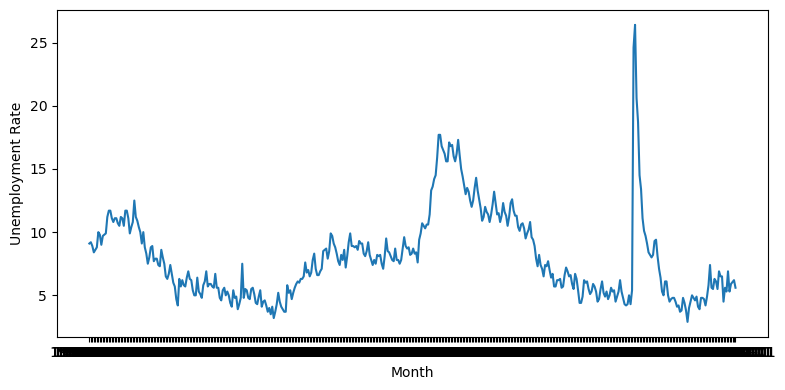

In [838]:
plt.figure(figsize=(8, 4))
plt.plot(unem_new['Date'], unem_new['Value'])
plt.xlabel('Month')
plt.ylabel('Unemployment Rate')
plt.tight_layout()
plt.show()

#not sure whats wrong with the x-axis?? Need to figure out

In [546]:
#FINDING COVID INDEX
monthly_counts_new.loc[monthly_counts_new["Date"] >= '2020-03-01'].head()

,Date,total
362,2020-03-01 00:00:00+00:00,2890
363,2020-04-01 00:00:00+00:00,2526
364,2020-05-01 00:00:00+00:00,2978
365,2020-06-01 00:00:00+00:00,3416
366,2020-07-01 00:00:00+00:00,3250


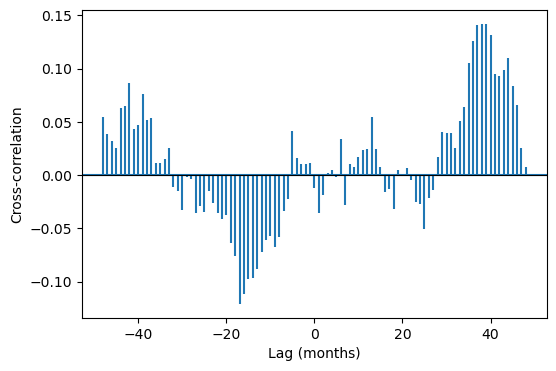

In [842]:
#CROSS CORRELATION
x = monthly_counts_new["total"] - monthly_counts_new["total"].mean()
y = unem_new["Value"] - unem_new["Value"].mean()

x_pre = x.loc[:362]
y_pre = y.loc[:362]

x_pre_sd = x_pre.diff(12).dropna()
y_pre_sd = y_pre.diff(12).dropna()

plt.figure(figsize=(6, 4))
plt.xcorr(y_pre_sd, x_pre_sd, maxlags=48, normed=True)

plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Lag (months)")
plt.ylabel("Cross-correlation")
plt.show()

In [843]:
#INDICATES THERE IS NOT REALLY AN ASSOCIATION BETWEEN UNEMPLOYMENT AND CRIME IN DETROIT PRE COVID AND AFTER REMOVING SEASONALITY

In [844]:
#creating a covid indicator var
#0 pre covid, 1 during covid, 2 post covid

monthly_counts_new["covid"] = np.select(
    [
        monthly_counts_new["Date"] < pd.Timestamp("2020-03-01", tz="UTC"),
        (monthly_counts_new["Date"] >= pd.Timestamp("2020-03-01", tz="UTC")) & (monthly_counts_new["Date"] < pd.Timestamp("2022-07-01", tz="UTC")),
        monthly_counts_new["Date"] >= pd.Timestamp("2022-07-01", tz="UTC"),
    ],
    ["pre", "during", "post"],
    default="unknown" 
)



monthly_counts_new["covid"] = pd.Categorical(
    monthly_counts_new["covid"],
    categories=["pre", "during", "post"],
    ordered=True
)

X = pd.get_dummies(monthly_counts_new["covid"], drop_first=True).astype(float)

In [845]:
# #CREATING EXOGENOUS VARIABLE MATRIX 
# mc = monthly_counts_new.copy()
# mc.index = pd.date_range("1990-01-01", periods=len(mc), freq="MS") 

# # ----- y with real dates -----
# y = mc["total"].rename("y")
# y.index = y.index.to_period("M").to_timestamp(how="start")
# idx_m = pd.DatetimeIndex(monthly_counts_new["Date"]).to_period("M")

# # ----- dummies -----
# X_arr = np.asarray(X)
# X_df = pd.DataFrame(X_arr[:, :2], index=idx_m, columns=["during","post"])

# # ----- unemployment (already date-indexed) -----
# u = unem_new["Value"].copy()
# #u.index = pd.DatetimeIndex(u.index).to_period("M")
# #u = u.reindex(idx_m)
# #u = monthly_unemploy["unemploy_rate"].copy()
# u = pd.Series(u.to_numpy(), index=idx_m, name="unemploy_rate")

# # ----- exog -----
# exog_data = pd.concat([X_df, u.rename("unemploy_rate")], axis=1)
# exog_dt = exog_data.copy()
# exog_dt.index = exog_dt.index.to_timestamp(how="start")

# print(exog_data.isna().sum())         # should be all zeros now
# print(exog_dt.index.equals(y.index))  # should be True

# exog_base = exog_dt.copy()

# t = np.arange(len(exog_base), dtype=float)
# t = (t - t.mean()) / t.std()   # optional but recommended

# exog_slope = exog_base.copy()
# exog_slope["t"] = t
# exog_slope["t_during"] = t * exog_slope["during"]

# # ----- df0 (aligned master frame) -----
# df0 = pd.concat([y, exog_dt], axis=1).dropna()
# y_aligned = df0["y"]
# X_aligned = df0.drop(columns="y")

during           0
post             0
unemploy_rate    0
dtype: int64
True


C:\Users\enora\AppData\Local\Temp\ipykernel_16852\2956794312.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  idx_m = pd.DatetimeIndex(monthly_counts_new["Date"]).to_period("M")


In [848]:
# y (violent)
y = monthly_counts_new["total"].copy()
y.index = pd.date_range("1990-01-01", periods=len(y), freq="MS")

idx_dt = y.index  # DatetimeIndex (month start)

# dummies
X_df = pd.DataFrame(np.asarray(X)[:, :2], index=idx_dt, columns=["during", "post"])

# unemployment (ensure numeric!)
u = pd.Series(pd.to_numeric(unem_new["Value"], errors="coerce").to_numpy(),
              index=idx_dt, name="unemploy_rate")

# exog + slope + interaction
exog = pd.concat([X_df, u], axis=1)

t = np.arange(len(exog), dtype=float)
t = (t - t.mean()) / t.std()
exog["t"] = t
exog["t_during"] = t * exog["during"]
exog['t_post'] = t * exog['post']

# align
df0 = pd.concat([y_prop.rename("y"), exog], axis=1).dropna()
y_aligned = df0["y"]
X_aligned = df0.drop(columns="y")

print(df0.shape)
print(y_aligned.head())

(432, 7)
1990-01-01    8829
1990-02-01    6991
1990-03-01    7860
1990-04-01    7648
1990-05-01    7281
Freq: MS, Name: y, dtype: int64


In [849]:
print(y_aligned.head())
print(X_aligned.head())

print(len(y_aligned))
print(len(X_aligned))

1990-01-01    8829
1990-02-01    6991
1990-03-01    7860
1990-04-01    7648
1990-05-01    7281
Freq: MS, Name: y, dtype: int64
            during  post  unemploy_rate         t  t_during  t_post
1990-01-01     0.0   0.0            9.1 -1.728046      -0.0    -0.0
1990-02-01     0.0   0.0            9.2 -1.720027      -0.0    -0.0
1990-03-01     0.0   0.0            8.9 -1.712009      -0.0    -0.0
1990-04-01     0.0   0.0            8.4 -1.703990      -0.0    -0.0
1990-05-01     0.0   0.0            8.6 -1.695971      -0.0    -0.0
432
432


In [850]:
print("y len:", len(y_aligned))
print("X len:", len(X_aligned))
print("index equal:", y_aligned.index.equals(X_aligned.index))

print(exog_aligned.dtypes)
print("Any NA in y:", y_aligned.isna().any())
print("Any NA in X:", X_aligned.isna().any().any())

y len: 432
X len: 432
index equal: True
during           float64
post             float64
unemploy_rate    float64
dtype: object
Any NA in y: False
Any NA in X: False


In [851]:
#MODEL SELECTION FUNCTION
def sarimax_aic_table(data, p_max, q_max, P_max, Q_max, m): # D = 1
    results = []
    # parallelize
    # Iterate through all combinations
    for p in range(p_max + 1):
        for q in range(q_max + 1):
            for P in range(P_max + 1):
                for Q in range(Q_max + 1):
                    try:
                        model = SARIMAX(data, order=(p,0,q), trend='c',
                        seasonal_order=(P, 0, Q, m), exog=X_aligned)
                        results_fit = model.fit(disp=False)
                        results.append([p, q, P, Q, results_fit.aic])
                    except:
                        results.append([p, q, P, Q, np.nan])
                        
    # Create DataFrame
    df = pd.DataFrame(results, columns=['AR(p)', 'MA(q)', 'SAR(P)', 'SMA(Q)', 'AIC'])
    df.sort_values(by='AIC')
    # Sort by AIC ascending
    return df.sort_values(by='AIC')

sarimax_results = sarimax_aic_table(y_aligned, 2, 1, 2, 1, 12)

C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximu

In [852]:
sarimax_results

,AR(p),MA(q),SAR(P),SMA(Q),AIC
20,1,1,1,0,6664.581593
19,1,1,0,1,6693.865129
21,1,1,1,1,6707.329746
26,2,0,1,0,6713.802158
25,2,0,0,1,6717.994719
28,2,0,2,0,6736.223706
29,2,0,2,1,6736.387509
23,1,1,2,1,6740.564640
18,1,1,0,0,6744.929232
22,1,1,2,0,6746.877398


In [911]:
new_mod = SARIMAX(
    np.log(y_aligned),
    exog=X_aligned,
    order=(1,0,0),
    seasonal_order=(1,0,0,12),
    trend="c"
).fit(disp=False)

print(new_mod.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  432
Model:             SARIMAX(1, 0, 0)x(1, 0, 0, 12)   Log Likelihood                 212.392
Date:                            Tue, 17 Feb 2026   AIC                           -404.784
Time:                                    20:33:28   BIC                           -364.100
Sample:                                01-01-1990   HQIC                          -388.722
                                     - 12-01-2025                                         
Covariance Type:                              opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
intercept         0.0043      0.014      0.318      0.750      -0.022       0.031
during          -72.9073  

C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


AR roots: [1.00299258]
MA roots: []


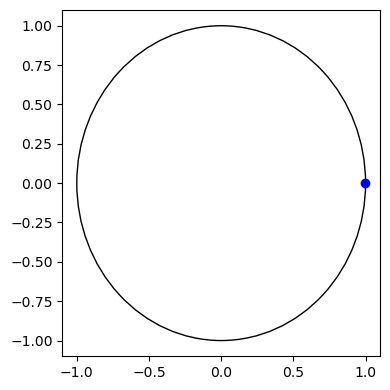

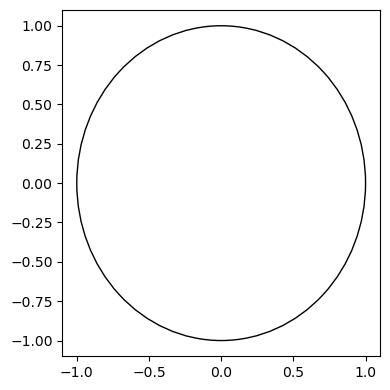

In [912]:
#NON SEASONAL ROOTS
ar_pars = new_mod.arparams 
ar_poly = np.polynomial.Polynomial(np.r_[1,-ar_pars]) 
print(f"AR roots: {ar_poly.roots()}")
inv_ar_roots = 1/ar_poly.roots()

ma_pars = new_mod.maparams 
ma_poly = np.polynomial.Polynomial(np.r_[1,-ma_pars]) 
print(f"MA roots: {ma_poly.roots()}")
inv_ma_roots = 1/ma_poly.roots()

fig, ax = plt.subplots(figsize=(4, 4))
unit_circle1 = patches.Circle((0, 0), radius=1, edgecolor='black', facecolor='None')
ax.add_patch(unit_circle1)
ax.scatter(np.real(inv_ar_roots), np.imag(inv_ar_roots), color='blue', marker='o', label="Inverse AR Roots")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(4, 4))
unit_circle1 = patches.Circle((0, 0), radius=1, edgecolor='black', facecolor='None')
ax.add_patch(unit_circle1)
ax.scatter(np.real(inv_ma_roots), np.imag(inv_ma_roots), color='blue', marker='o', label="Inverse AR Roots")

plt.tight_layout()
plt.show()

C:\Users\enora\AppData\Local\Temp\ipykernel_16852\1717699080.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  phi_S12 = new_mod.params[new_mod.param_names.index("ar.S.L12")]


Seasonal AR roots: [-1.05501237e+00+0.j         -9.13667511e-01+0.52750618j
 -9.13667511e-01-0.52750618j -5.27506184e-01+0.91366751j
 -5.27506184e-01-0.91366751j -4.85287112e-16+1.05501237j
 -4.85287112e-16-1.05501237j  5.27506184e-01+0.91366751j
  5.27506184e-01-0.91366751j  1.05501237e+00+0.j
  9.13667511e-01+0.52750618j  9.13667511e-01-0.52750618j]


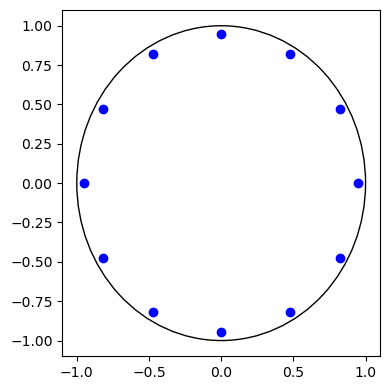

In [913]:
#SEASONAL ROOTS
phi_S12 = new_mod.params[new_mod.param_names.index("ar.S.L12")]
s = 12

# Build seasonal AR polynomial: 1 - phi * L^12
sar_poly = np.zeros(s + 1)
sar_poly[0] = 1.0
sar_poly[s] = -phi_S12

# Roots and inverse roots
sar_roots = np.roots(sar_poly[::-1])
inv_sar_roots = 1 / sar_roots

print(f"Seasonal AR roots: {sar_roots}")

fig, ax = plt.subplots(figsize=(4, 4))
unit_circle1 = patches.Circle((0, 0), radius=1, edgecolor='black', facecolor='None')
ax.add_patch(unit_circle1)
ax.scatter(np.real(inv_sar_roots), np.imag(inv_sar_roots), color='blue', marker='o', label="Inverse AR Roots")

plt.tight_layout()
plt.show()

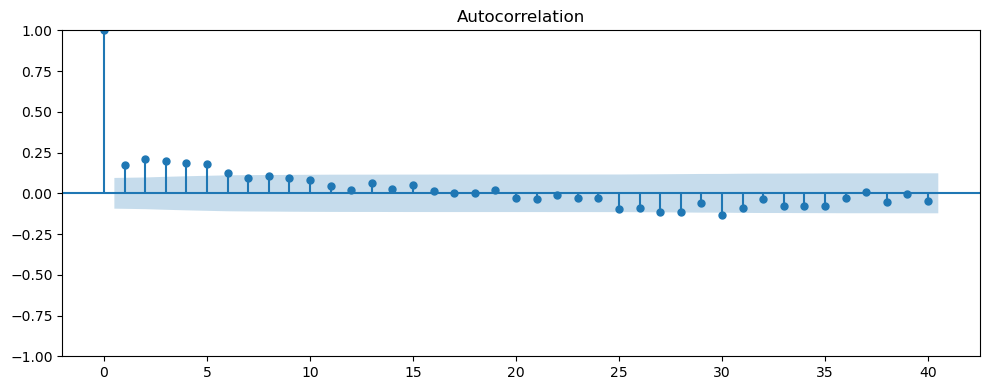

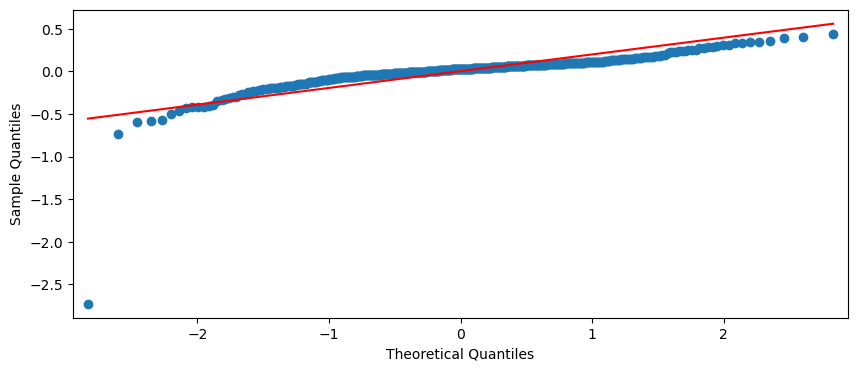

In [914]:
#RESIDUAL CHECKS- ACF PLOT AND QQ PLOT
new_resids = new_mod.resid

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(new_resids, ax=ax, lags=40)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
sm.qqplot(new_resids, line='s', ax=ax)
plt.show()

In [559]:
#ALREADY TRIED LOG TRANSFORM, DID NOT HELP RESIDUALS

In [560]:
# Assume y_aligned and X_aligned share the same index already
df = pd.concat([y_aligned.rename("y"), X_aligned], axis=1).dropna()

t = np.arange(len(df), dtype=float)  # 0,1,2,... (time index)

# COVID regime indicators (adjust names to yours)
during = df["during"].astype(float)
post   = df["post"].astype(float)

# Build exog with regime-specific intercept and slope changes
exog_regime = pd.DataFrame({
    "unemploy_rate": df["unemploy_rate"].astype(float),

    # baseline time trend
    "t": t,

    # level shifts
    "during": during,
    "post": post,

    # slope shifts (this is the key!)
    "t_during": t * during,
    "t_post":   t * post,
}, index=df.index)

mod = SARIMAX(
    df["y"],
    exog=exog_regime,
    order=(2,0,0),
    seasonal_order=(1,0,0,12),
    trend="n",  # IMPORTANT: no built-in intercept/trend (avoid duplicates)
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(mod.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  432
Model:             SARIMAX(2, 0, 0)x(1, 0, 0, 12)   Log Likelihood               -3434.354
Date:                            Tue, 17 Feb 2026   AIC                           6888.708
Time:                                    10:13:52   BIC                           6929.063
Sample:                                01-01-1990   HQIC                          6904.661
                                     - 12-01-2025                                         
Covariance Type:                              opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
unemploy_rate    80.9528     26.257      3.083      0.002      29.490     132.416
t              -377.0896  

C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


AR roots: [-1.44185692  0.99767005]


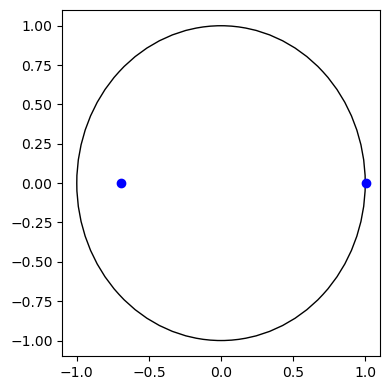

In [561]:
#NON SEASONAL ROOTS
ar_pars = mod.arparams 
ar_poly = np.polynomial.Polynomial(np.r_[1,-ar_pars]) 
print(f"AR roots: {ar_poly.roots()}")
inv_ar_roots = 1/ar_poly.roots()

fig, ax = plt.subplots(figsize=(4, 4))
unit_circle1 = patches.Circle((0, 0), radius=1, edgecolor='black', facecolor='None')
ax.add_patch(unit_circle1)
ax.scatter(np.real(inv_ar_roots), np.imag(inv_ar_roots), color='blue', marker='o', label="Inverse AR Roots")

plt.tight_layout()
plt.show()

Seasonal AR roots: [-1.10288090e+00+0.j         -9.55122876e-01+0.55144045j
 -9.55122876e-01-0.55144045j -5.51440449e-01+0.95512288j
 -5.51440449e-01-0.95512288j -2.30543044e-16+1.1028809j
 -2.30543044e-16-1.1028809j   5.51440449e-01+0.95512288j
  5.51440449e-01-0.95512288j  1.10288090e+00+0.j
  9.55122876e-01+0.55144045j  9.55122876e-01-0.55144045j]


C:\Users\enora\AppData\Local\Temp\ipykernel_16852\1432747619.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  phi_S12 = mod.params[new_mod.param_names.index("ar.S.L12")]


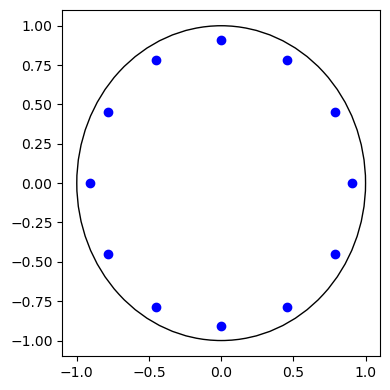

In [562]:
#SEASONAL ROOTS
phi_S12 = mod.params[new_mod.param_names.index("ar.S.L12")]
s = 12

# Build seasonal AR polynomial: 1 - phi * L^12
sar_poly = np.zeros(s + 1)
sar_poly[0] = 1.0
sar_poly[s] = -phi_S12

# Roots and inverse roots
sar_roots = np.roots(sar_poly[::-1])
inv_sar_roots = 1 / sar_roots

print(f"Seasonal AR roots: {sar_roots}")

fig, ax = plt.subplots(figsize=(4, 4))
unit_circle1 = patches.Circle((0, 0), radius=1, edgecolor='black', facecolor='None')
ax.add_patch(unit_circle1)
ax.scatter(np.real(inv_sar_roots), np.imag(inv_sar_roots), color='blue', marker='o', label="Inverse AR Roots")

plt.tight_layout()
plt.show()

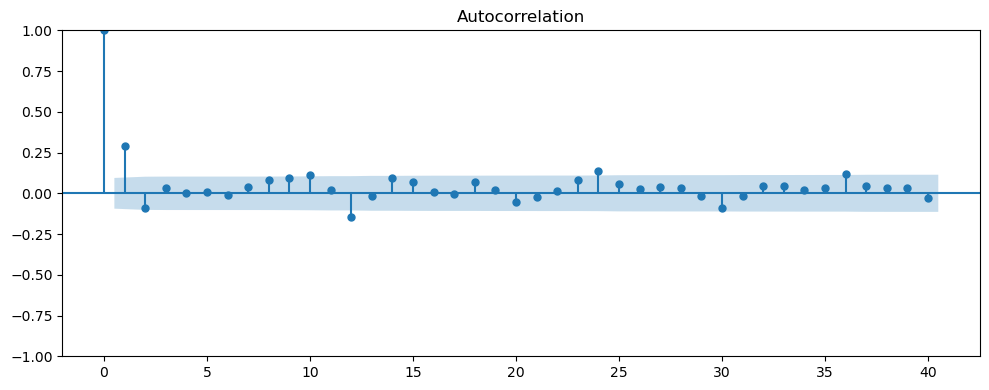

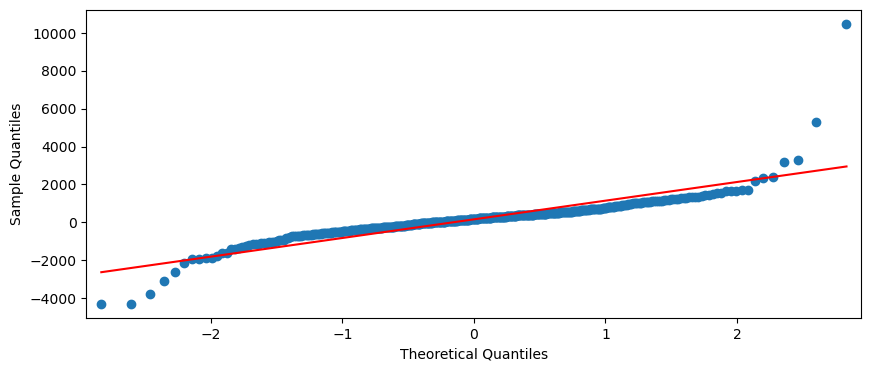

In [563]:
#RESIDUAL CHECKS- ACF PLOT AND QQ PLOT
resids = mod.resid

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(resids, ax=ax, lags=40)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
sm.qqplot(resids, line='s', ax=ax)
plt.show()

In [787]:
#SPLITTING UP MODELS BY DIFFRERENT TYPES OF CRIME

crime_new['Date'].head()

crime_new["Date"] = pd.to_datetime(
    crime_new["Date"],
    utc=True
)


crime_ts_new = crime_new[
    (crime_new["Date"] >= "1990-01-01") &
    (crime_new["Date"] <  "2026-01-01")
]


monthly_counts_prop = (
    crime_ts_new
    .set_index("Date")["Property_Crime"]
    .resample("MS")
    .sum()
    .rename("property")
    .reset_index()
)

print("Monthly points:", len(monthly_counts_prop))

print(monthly_counts_prop.head())

Monthly points: 432
                       Date  property
0 1990-01-01 00:00:00+00:00      8829
1 1990-02-01 00:00:00+00:00      6991
2 1990-03-01 00:00:00+00:00      7860
3 1990-04-01 00:00:00+00:00      7648
4 1990-05-01 00:00:00+00:00      7281


In [788]:
#creating a covid indicator var
#0 pre covid, 1 during covid, 2 post covid

monthly_counts_prop["covid"] = np.select(
    [
        monthly_counts_prop["Date"] < pd.Timestamp("2020-03-01", tz="UTC"),
        (monthly_counts_prop["Date"] >= pd.Timestamp("2020-03-01", tz="UTC")) & (monthly_counts_prop["Date"] < pd.Timestamp("2022-07-01", tz="UTC")),
        monthly_counts_prop["Date"] >= pd.Timestamp("2022-07-01", tz="UTC"),
    ],
    ["pre", "during", "post"],
    default="unknown" 
)



monthly_counts_prop["covid"] = pd.Categorical(
    monthly_counts_prop["covid"],
    categories=["pre", "during", "post"],
    ordered=True
)

X = pd.get_dummies(monthly_counts_prop["covid"], drop_first=True).astype(float)

In [789]:
# #CREATING EXOGENOUS VARIABLE MATRIX 
# mc = monthly_counts_prop.copy()
# mc.index = pd.date_range("1990-01-01", periods=len(mc), freq="MS") 

# # ----- y with real dates -----
# y = mc["property"].rename("y")
# y.index = y.index.to_period("M").to_timestamp(how="start")
# idx_m = pd.DatetimeIndex(monthly_counts_new["Date"]).to_period("M")

# # ----- dummies -----
# X_arr = np.asarray(X)
# X_df = pd.DataFrame(X_arr[:, :2], index=idx_m, columns=["during","post"])

# # ----- unemployment (already date-indexed) -----
# u = unem_new["Value"].copy()
# #u.index = pd.DatetimeIndex(u.index).to_period("M")
# #u = u.reindex(idx_m)
# #u = monthly_unemploy["unemploy_rate"].copy()
# u = pd.Series(u.to_numpy(), index=idx_m, name="unemploy_rate")

# # ----- exog -----
# exog_data = pd.concat([X_df, u.rename("unemploy_rate")], axis=1)
# exog_dt = exog_data.copy()
# exog_dt.index = exog_dt.index.to_timestamp(how="start")

# exog_base = exog_dt.copy()

# t = np.arange(len(exog_base), dtype=float)
# t = (t - t.mean()) / t.std()   # optional but recommended

# exog_slope = exog_base.copy()
# exog_slope["t"] = t
# exog_slope["t_during"] = t * exog_slope["during"]

# # ----- df0 (aligned master frame) -----
# df0 = pd.concat([y.rename("y"), exog_slope], axis=1).dropna()

# y_aligned_prop = df0["y"]
# X_aligned_prop = df0.drop(columns="y")

In [790]:
# y (violent)
y_prop = monthly_counts_prop["property"].copy()
y_prop.index = pd.date_range("1990-01-01", periods=len(y_vio), freq="MS")

idx_dt = y_prop.index  # DatetimeIndex (month start)

# dummies
X_df = pd.DataFrame(np.asarray(X)[:, :2], index=idx_dt, columns=["during", "post"])

# unemployment (ensure numeric!)
u = pd.Series(pd.to_numeric(unem_new["Value"], errors="coerce").to_numpy(),
              index=idx_dt, name="unemploy_rate")

# exog + slope + interaction
exog = pd.concat([X_df, u], axis=1)

t = np.arange(len(exog), dtype=float)
t = (t - t.mean()) / t.std()
exog["t"] = t
exog["t_during"] = t * exog["during"]
exog['t_post'] = t * exog['post']

# align
df0 = pd.concat([y_prop.rename("y"), exog], axis=1).dropna()
y_aligned_prop = df0["y"]
X_aligned_prop = df0.drop(columns="y")

print(df0.shape)
print(y_aligned_prop.head())

(432, 7)
1990-01-01    8829
1990-02-01    6991
1990-03-01    7860
1990-04-01    7648
1990-05-01    7281
Freq: MS, Name: y, dtype: int64


In [791]:
monthly_counts_prop.head()

,Date,property,covid
0,1990-01-01 00:00:00+00:00,8829,pre
1,1990-02-01 00:00:00+00:00,6991,pre
2,1990-03-01 00:00:00+00:00,7860,pre
3,1990-04-01 00:00:00+00:00,7648,pre
4,1990-05-01 00:00:00+00:00,7281,pre


In [812]:
#MODEL SELECTION FUNCTION
def sarimax_aic_table(data, p_max, q_max, P_max, Q_max, m): # D = 1
    results = []
    # parallelize
    # Iterate through all combinations
    for p in range(p_max + 1):
        for q in range(q_max + 1):
            for P in range(P_max + 1):
                for Q in range(Q_max + 1):
                    try:
                        model = SARIMAX(data, order=(p,0,q), trend='c',
                        seasonal_order=(P, 0, Q, m), exog=X_aligned_prop)
                        results_fit = model.fit(disp=False)
                        results.append([p, q, P, Q, results_fit.aic])
                    except:
                        results.append([p, q, P, Q, np.nan])
                        
    # Create DataFrame
    df = pd.DataFrame(results, columns=['AR(p)', 'MA(q)', 'SAR(P)', 'SMA(Q)', 'AIC'])
    df.sort_values(by='AIC')
    # Sort by AIC ascending
    return df.sort_values(by='AIC')

sarimax_results_prop = sarimax_aic_table(y_aligned_prop, 2, 1, 1, 1, 12)

C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximu

In [813]:
sarimax_results_prop

,AR(p),MA(q),SAR(P),SMA(Q),AIC
14,1,1,1,0,6664.581593
13,1,1,0,1,6693.865129
15,1,1,1,1,6707.329746
18,2,0,1,0,6713.802158
17,2,0,0,1,6717.994719
12,1,1,0,0,6744.929232
16,2,0,0,0,6750.322380
19,2,0,1,1,6759.596745
10,1,0,1,0,6774.695271
23,2,1,1,1,6781.191585


In [826]:
new_mod = SARIMAX(
    y_aligned_prop,
    exog=X_aligned_prop,
    order=(1,0,1),
    seasonal_order=(1,0,0,12),
    trend="c"
).fit(disp=False)

print(new_mod.summary())

                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                  432
Model:             SARIMAX(1, 0, 1)x(1, 0, [], 12)   Log Likelihood               -3321.291
Date:                             Tue, 17 Feb 2026   AIC                           6664.582
Time:                                     20:08:29   BIC                           6709.334
Sample:                                 01-01-1990   HQIC                          6682.250
                                      - 12-01-2025                                         
Covariance Type:                               opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
intercept        62.7025     45.833      1.368      0.171     -27.128     152.533
during        -4.6

C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


AR roots: [1.03766617]
MA roots: [-1.733544]


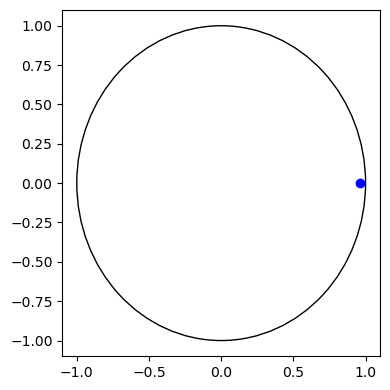

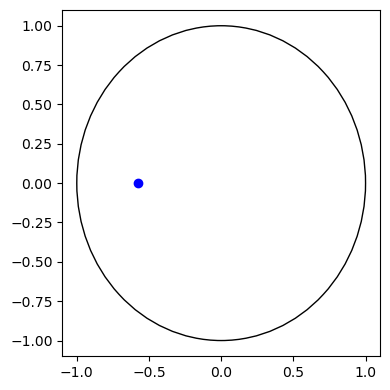

In [827]:
#NON SEASONAL ROOTS
ar_pars = new_mod.arparams 
ar_poly = np.polynomial.Polynomial(np.r_[1,-ar_pars]) 
print(f"AR roots: {ar_poly.roots()}")
inv_ar_roots = 1/ar_poly.roots()


ma_pars = new_mod.maparams 
ma_poly = np.polynomial.Polynomial(np.r_[1,-ma_pars]) 
print(f"MA roots: {ma_poly.roots()}")
inv_ma_roots = 1/ma_poly.roots()

fig, ax = plt.subplots(figsize=(4, 4))
unit_circle1 = patches.Circle((0, 0), radius=1, edgecolor='black', facecolor='None')
ax.add_patch(unit_circle1)
ax.scatter(np.real(inv_ar_roots), np.imag(inv_ar_roots), color='blue', marker='o', label="Inverse AR Roots")

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(4, 4))
unit_circle1 = patches.Circle((0, 0), radius=1, edgecolor='black', facecolor='None')
ax.add_patch(unit_circle1)
ax.scatter(np.real(inv_ma_roots), np.imag(inv_ma_roots), color='blue', marker='o', label="Inverse MA Roots")

plt.tight_layout()
plt.show()

C:\Users\enora\AppData\Local\Temp\ipykernel_16852\1717699080.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  phi_S12 = new_mod.params[new_mod.param_names.index("ar.S.L12")]


Seasonal AR roots: [-1.06632213e+00+0.j         -9.23462049e-01+0.53316106j
 -9.23462049e-01-0.53316106j -5.33161063e-01+0.92346205j
 -5.33161063e-01-0.92346205j  9.38713042e-17+1.06632213j
  9.38713042e-17-1.06632213j  5.33161063e-01+0.92346205j
  5.33161063e-01-0.92346205j  1.06632213e+00+0.j
  9.23462049e-01+0.53316106j  9.23462049e-01-0.53316106j]


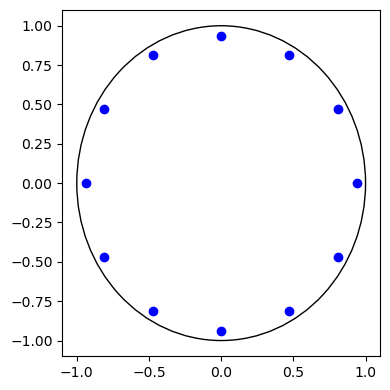

In [828]:
#SEASONAL ROOTS
phi_S12 = new_mod.params[new_mod.param_names.index("ar.S.L12")]
s = 12

# Build seasonal AR polynomial: 1 - phi * L^12
sar_poly = np.zeros(s + 1)
sar_poly[0] = 1.0
sar_poly[s] = -phi_S12

# Roots and inverse roots
sar_roots = np.roots(sar_poly[::-1])
inv_sar_roots = 1 / sar_roots

print(f"Seasonal AR roots: {sar_roots}")

fig, ax = plt.subplots(figsize=(4, 4))
unit_circle1 = patches.Circle((0, 0), radius=1, edgecolor='black', facecolor='None')
ax.add_patch(unit_circle1)
ax.scatter(np.real(inv_sar_roots), np.imag(inv_sar_roots), color='blue', marker='o', label="Inverse AR Roots")

plt.tight_layout()
plt.show()

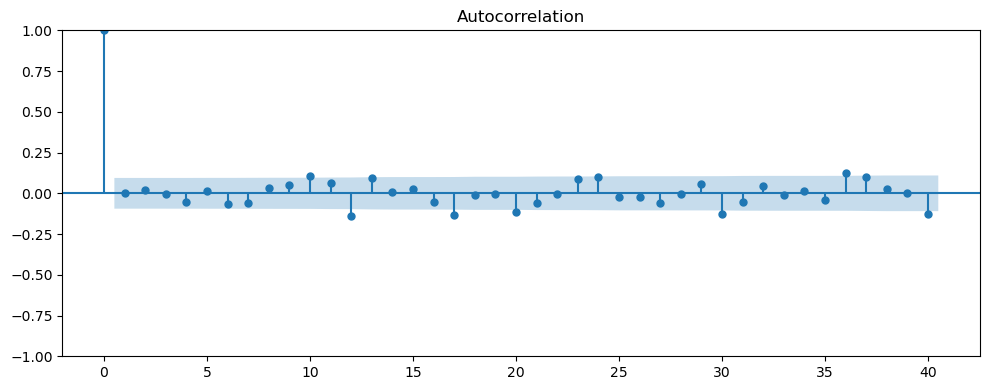

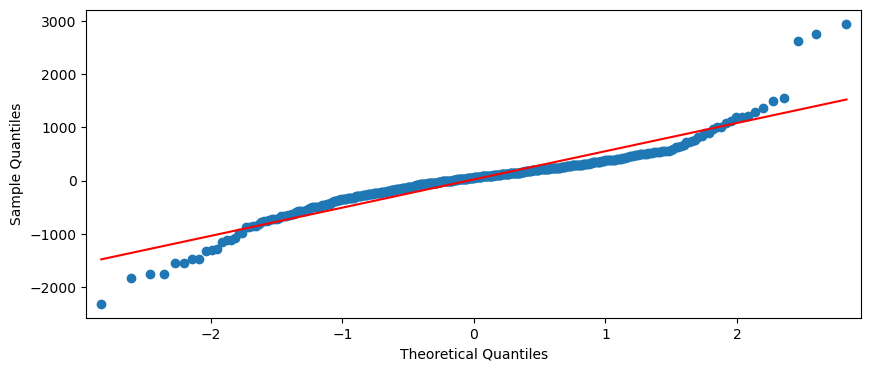

In [829]:
#RESIDUAL CHECKS- ACF PLOT AND QQ PLOT
resids = new_mod.resid

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(resids, ax=ax, lags=40)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
sm.qqplot(resids, line='s', ax=ax)
plt.show()

In [831]:

resids.abs().sort_values(ascending=False).head(10)

2020-03-01    2947.529022
1998-01-01    2747.456437
2002-12-01    2632.448163
1999-01-01    2310.183469
1990-02-01    1823.356947
1998-03-01    1761.061815
2021-03-01    1750.435577
1996-07-01    1554.171499
1994-01-01    1542.039707
2002-02-01    1541.058101
dtype: float64

In [811]:
#AGAIN, LOG ACTUALLY MADE THE FIT WORSE

In [696]:
#SPLITTING UP MODELS BY DIFFRERENT TYPES OF CRIME

crime_new['Date'].head()

crime_new["Date"] = pd.to_datetime(
    crime_new["Date"],
    utc=True
)


crime_ts_new = crime_new[
    (crime_new["Date"] >= "1990-01-01") &
    (crime_new["Date"] <  "2026-01-01")
]


monthly_counts_vio = (
    crime_ts_new
    .set_index("Date")["Violent_Crime"]
    .resample("MS")
    .sum()
    .rename("violent")
    .reset_index()
)

print("Monthly points:", len(monthly_counts_vio))

print(monthly_counts_vio.head())

Monthly points: 432
                       Date  violent
0 1990-01-01 00:00:00+00:00     2385
1 1990-02-01 00:00:00+00:00     1903
2 1990-03-01 00:00:00+00:00     2116
3 1990-04-01 00:00:00+00:00     2105
4 1990-05-01 00:00:00+00:00     2387


In [697]:
#creating a covid indicator var
#0 pre covid, 1 during covid, 2 post covid

monthly_counts_vio["covid"] = np.select(
    [
        monthly_counts_vio["Date"] < pd.Timestamp("2020-03-01", tz="UTC"),
        (monthly_counts_vio["Date"] >= pd.Timestamp("2020-03-01", tz="UTC")) & (monthly_counts_vio["Date"] < pd.Timestamp("2022-07-01", tz="UTC")),
        monthly_counts_vio["Date"] >= pd.Timestamp("2022-07-01", tz="UTC"),
    ],
    ["pre", "during", "post"],
    default="unknown" 
)



monthly_counts_vio["covid"] = pd.Categorical(
    monthly_counts_vio["covid"],
    categories=["pre", "during", "post"],
    ordered=True
)

X = pd.get_dummies(monthly_counts_vio["covid"], drop_first=True).astype(float)

In [698]:
# #CREATING EXOGENOUS VARIABLE MATRIX 
# mc = monthly_counts_vio.copy()
# mc.index = pd.date_range("1990-01-01", periods=len(mc), freq="MS") 

# # ----- y with real dates -----
# y = mc["violent"].rename("y")
# y.index = y.index.to_period("M").to_timestamp(how="start")
# idx_m = pd.DatetimeIndex(monthly_counts_new["Date"]).to_period("M")

# # ----- dummies -----
# X_arr = np.asarray(X)
# X_df = pd.DataFrame(X_arr[:, :2], index=idx_m, columns=["during","post"])

# # ----- unemployment (already date-indexed) -----
# u = unem_new["Value"].copy()
# #u.index = pd.DatetimeIndex(u.index).to_period("M")
# #u = u.reindex(idx_m)
# #u = monthly_unemploy["unemploy_rate"].copy()
# u = pd.Series(u.to_numpy(), index=idx_m, name="unemploy_rate")

# # ----- exog -----
# exog_data = pd.concat([X_df, u.rename("unemploy_rate")], axis=1)
# exog_dt = exog_data.copy()
# exog_dt.index = exog_dt.index.to_timestamp(how="start")

# exog_base = exog_dt.copy()


# t = np.arange(len(exog_base), dtype=float)
# t = (t - t.mean()) / t.std()   # optional but recommended

# exog_slope = exog_base.copy()
# exog_slope["t"] = t
# exog_slope["t_during"] = t * exog_slope["during"]

# # ----- df0 (aligned master frame) -----
# df0 = pd.concat([y.rename("y"), exog_slope], axis=1).dropna()

# y_aligned_vio = df0["y"]
# X_aligned_vio = df0.drop(columns="y")

In [710]:
# y (violent)
y_vio = monthly_counts_vio["violent"].copy()
y_vio.index = pd.date_range("1990-01-01", periods=len(y_vio), freq="MS")

idx_dt = y_vio.index  # DatetimeIndex (month start)

# dummies
X_df = pd.DataFrame(np.asarray(X)[:, :2], index=idx_dt, columns=["during", "post"])

# unemployment (ensure numeric!)
u = pd.Series(pd.to_numeric(unem_new["Value"], errors="coerce").to_numpy(),
              index=idx_dt, name="unemploy_rate")

# exog + slope + interaction
exog = pd.concat([X_df, u], axis=1)

t = np.arange(len(exog), dtype=float)
t = (t - t.mean()) / t.std()
exog["t"] = t
exog["t_during"] = t * exog["during"]
exog['t_post'] = t * exog['post']

# align
df0 = pd.concat([y_vio.rename("y"), exog], axis=1).dropna()
y_aligned_vio = df0["y"]
X_aligned_vio = df0.drop(columns="y")

print(df0.shape)
print(y_aligned_vio.head())

(432, 7)
1990-01-01    2385
1990-02-01    1903
1990-03-01    2116
1990-04-01    2105
1990-05-01    2387
Freq: MS, Name: y, dtype: int64


In [758]:
#MODEL SELECTION FUNCTION
def sarimax_aic_table(data, p_max, q_max, P_max, Q_max, m): # D = 1
    results = []
    # parallelize
    # Iterate through all combinations
    for p in range(p_max + 1):
        for q in range(q_max + 1):
            for P in range(P_max + 1):
                for Q in range(Q_max + 1):
                    try:
                        model = SARIMAX(data, order=(p,0,q), trend='c',
                        seasonal_order=(P, 0, Q, m), exog=X_aligned_vio)
                        results_fit = model.fit(disp=False)
                        results.append([p, q, P, Q, results_fit.aic])
                    except:
                        results.append([p, q, P, Q, np.nan])
                        
    # Create DataFrame
    df = pd.DataFrame(results, columns=['AR(p)', 'MA(q)', 'SAR(P)', 'SMA(Q)', 'AIC'])
    df.sort_values(by='AIC')
    # Sort by AIC ascending
    return df.sort_values(by='AIC')


sarimax_results_vio = sarimax_aic_table(y_aligned_vio, 2, 1, 2, 1, 12)

C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximu

In [759]:
sarimax_results_vio

,AR(p),MA(q),SAR(P),SMA(Q),AIC
21,1,1,1,1,5708.530289
15,1,0,1,1,5757.474433
22,1,1,2,0,5766.196022
28,2,0,2,0,5776.626557
29,2,0,2,1,5785.166662
20,1,1,1,0,5798.059410
26,2,0,1,0,5810.899905
16,1,0,2,0,5815.093602
23,1,1,2,1,5818.529558
14,1,0,1,0,5834.880691


In [782]:
new_mod = SARIMAX(
    np.sqrt(y_aligned_vio),
    exog=X_aligned_vio,
    order=(1,0,1),
    seasonal_order=(2,0,0,12),
    trend="c"
).fit(disp=False)

print(new_mod.summary())

                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                  432
Model:             SARIMAX(1, 0, 1)x(1, 0, [], 12)   Log Likelihood               -1004.622
Date:                             Tue, 17 Feb 2026   AIC                           2031.243
Time:                                     20:00:52   BIC                           2075.996
Sample:                                 01-01-1990   HQIC                          2048.912
                                      - 12-01-2025                                         
Covariance Type:                               opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
intercept         0.1251      0.232      0.539      0.590      -0.330       0.580
during         -31

C:\Users\enora\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


AR roots: [1.01268917]
MA roots: [-3.11669753]


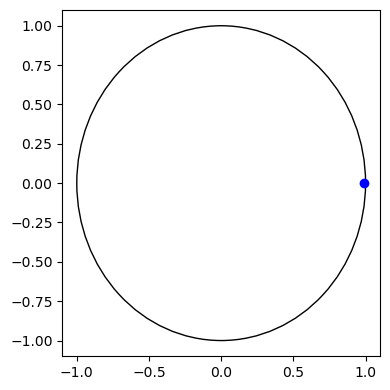

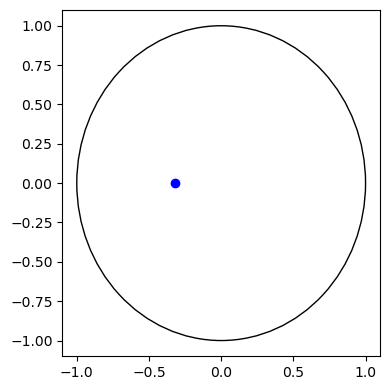

In [783]:
#NON SEASONAL ROOTS
ar_pars = new_mod.arparams 
ar_poly = np.polynomial.Polynomial(np.r_[1,-ar_pars]) 
print(f"AR roots: {ar_poly.roots()}")
inv_ar_roots = 1/ar_poly.roots()


ma_pars = new_mod.maparams 
ma_poly = np.polynomial.Polynomial(np.r_[1,-ma_pars]) 
print(f"MA roots: {ma_poly.roots()}")
inv_ma_roots = 1/ma_poly.roots()

fig, ax = plt.subplots(figsize=(4, 4))
unit_circle1 = patches.Circle((0, 0), radius=1, edgecolor='black', facecolor='None')
ax.add_patch(unit_circle1)
ax.scatter(np.real(inv_ar_roots), np.imag(inv_ar_roots), color='blue', marker='o', label="Inverse AR Roots")

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(4, 4))
unit_circle1 = patches.Circle((0, 0), radius=1, edgecolor='black', facecolor='None')
ax.add_patch(unit_circle1)
ax.scatter(np.real(inv_ma_roots), np.imag(inv_ma_roots), color='blue', marker='o', label="Inverse MA Roots")

plt.tight_layout()
plt.show()

Seasonal AR roots: [-1.05334324e+00+0.j         -9.12222004e-01+0.52667162j
 -9.12222004e-01-0.52667162j -5.26671620e-01+0.912222j
 -5.26671620e-01-0.912222j   -3.19156002e-16+1.05334324j
 -3.19156002e-16-1.05334324j  5.26671620e-01+0.912222j
  5.26671620e-01-0.912222j    1.05334324e+00+0.j
  9.12222004e-01+0.52667162j  9.12222004e-01-0.52667162j]


C:\Users\enora\AppData\Local\Temp\ipykernel_16852\1717699080.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  phi_S12 = new_mod.params[new_mod.param_names.index("ar.S.L12")]


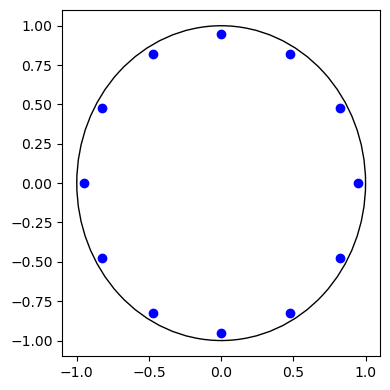

In [784]:
#SEASONAL ROOTS
phi_S12 = new_mod.params[new_mod.param_names.index("ar.S.L12")]
s = 12

# Build seasonal AR polynomial: 1 - phi * L^12
sar_poly = np.zeros(s + 1)
sar_poly[0] = 1.0
sar_poly[s] = -phi_S12

# Roots and inverse roots
sar_roots = np.roots(sar_poly[::-1])
inv_sar_roots = 1 / sar_roots

print(f"Seasonal AR roots: {sar_roots}")

fig, ax = plt.subplots(figsize=(4, 4))
unit_circle1 = patches.Circle((0, 0), radius=1, edgecolor='black', facecolor='None')
ax.add_patch(unit_circle1)
ax.scatter(np.real(inv_sar_roots), np.imag(inv_sar_roots), color='blue', marker='o', label="Inverse AR Roots")

plt.tight_layout()
plt.show()

In [785]:
#SEASONAL ROOTS
phi_S24 = new_mod.params[new_mod.param_names.index("ar.S.L24")]
s = 24

sar_poly = np.zeros(s + 1)
sar_poly[0] = 1.0
sar_poly[s] = -phi_S24

# Roots and inverse roots
sar_roots = np.roots(sar_poly[::-1])
inv_sar_roots = 1 / sar_roots

print(f"Seasonal AR roots: {sar_roots}")

fig, ax = plt.subplots(figsize=(4, 4))
unit_circle1 = patches.Circle((0, 0), radius=1, edgecolor='black', facecolor='None')
ax.add_patch(unit_circle1)
ax.scatter(np.real(inv_sar_roots), np.imag(inv_sar_roots), color='blue', marker='o', label="Inverse AR Roots")

plt.tight_layout()
plt.show()

ValueError: 'ar.S.L24' is not in list

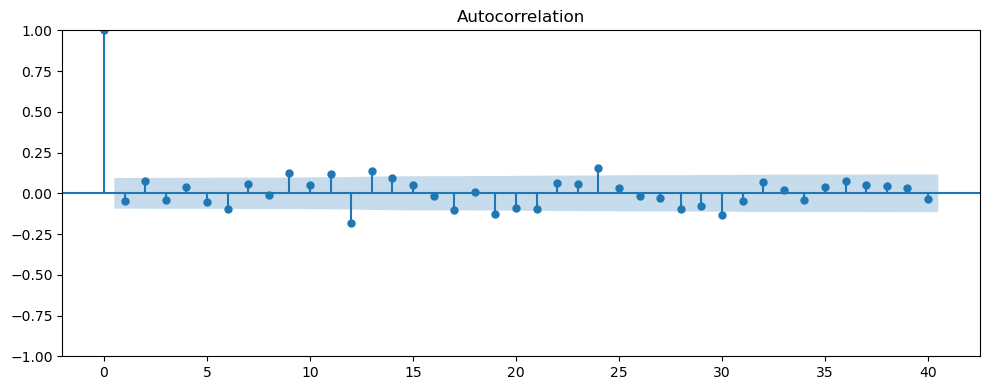

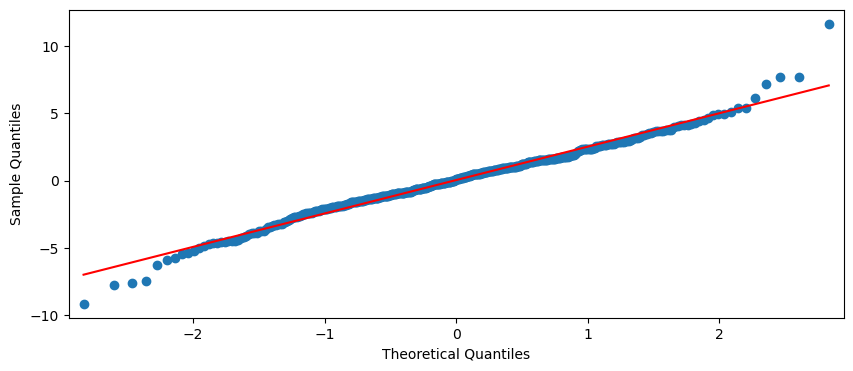

In [786]:
#RESIDUAL CHECKS- ACF PLOT AND QQ PLOT
resids = new_mod.resid

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(resids, ax=ax, lags=40)
plt.tight_layout()
plt.show()



fig, ax = plt.subplots(figsize=(10, 4))
sm.qqplot(resids, line='s', ax=ax)
plt.show()

In [585]:
from statsmodels.tsa.stattools import kpss

stat, pval, _, _ = kpss(y_aligned, regression="c", nlags="auto")
stat, pval

C:\Users\enora\AppData\Local\Temp\ipykernel_16852\1882104356.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, pval, _, _ = kpss(y_aligned, regression="c", nlags="auto")


(np.float64(3.4298951804400644), np.float64(0.01))

In [586]:
from hurst import compute_Hc

H, c, _ = compute_Hc(y_aligned, kind="price", simplified=True)
H

np.float64(0.45331504230247516)

In [667]:
print(monthly_counts_prop["property"].head())
print(monthly_counts_vio["violent"].head())

print("Series identical?",
      monthly_counts_prop["property"].reset_index(drop=True).equals(
          monthly_counts_vio["violent"].reset_index(drop=True)
      ))

print("Correlation:",
      monthly_counts_prop["property"].corr(monthly_counts_vio["violent"]))

0    8829
1    6991
2    7860
3    7648
4    7281
Name: property, dtype: int64
0    2385
1    1903
2    2116
3    2105
4    2387
Name: violent, dtype: int64
Series identical? False
Correlation: 0.8846983667293132


In [669]:
# Are the actual y vectors identical?
print("y_aligned_vio equals y_aligned:", y_aligned_vio.equals(y_aligned))

# Compare a few values with index
print(pd.concat([y_aligned_vio.rename("vio"), y_aligned.rename("other")], axis=1).head(10))
print(pd.concat([y_aligned_vio.rename("vio"), y_aligned.rename("other")], axis=1).tail(10))

# Numeric difference summary (works even if names/metadata differ)
diff = (y_aligned_vio - y_aligned).dropna()
print("max abs diff:", diff.abs().max())
print("nonzero diffs:", (diff != 0).sum())

# Are you accidentally pointing to the same object?
print("same python object:", y_aligned_vio is y_aligned)
print("same numpy buffer:", np.shares_memory(np.asarray(y_aligned_vio), np.asarray(y_aligned)))

y_aligned_vio equals y_aligned: True
             vio  other
1990-01-01  2385   2385
1990-02-01  1903   1903
1990-03-01  2116   2116
1990-04-01  2105   2105
1990-05-01  2387   2387
1990-06-01  2502   2502
1990-07-01  2502   2502
1990-08-01  2692   2692
1990-09-01  2398   2398
1990-10-01  2356   2356
             vio  other
2025-03-01   844    844
2025-04-01   850    850
2025-05-01   953    953
2025-06-01  1132   1132
2025-07-01  1156   1156
2025-08-01  1058   1058
2025-09-01   920    920
2025-10-01   866    866
2025-11-01   814    814
2025-12-01   699    699
max abs diff: 0
nonzero diffs: 0
same python object: False
same numpy buffer: False


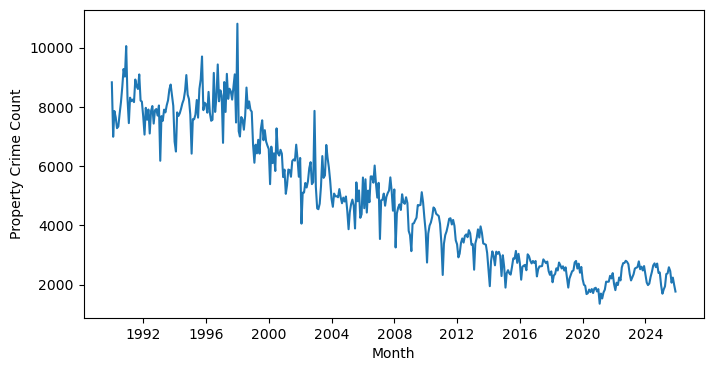

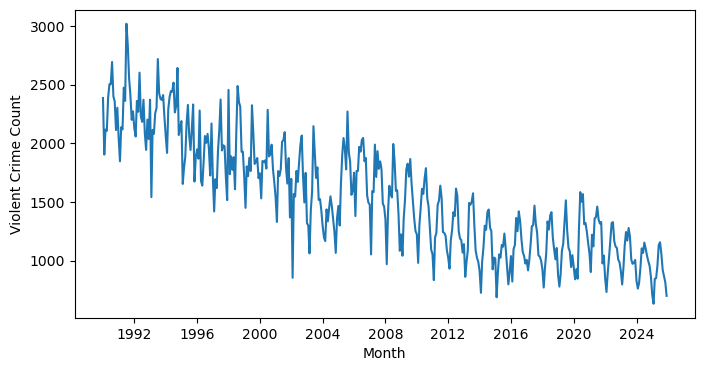

In [841]:
plt.figure(figsize=(8, 4))
plt.plot(monthly_counts_prop['Date'], monthly_counts_prop["property"])
plt.xlabel('Month'); plt.ylabel('Property Crime Count'); plt.show()

plt.figure(figsize=(8, 4))
plt.plot(monthly_counts_vio['Date'], monthly_counts_vio["violent"])
plt.xlabel('Month'); plt.ylabel('Violent Crime Count'); plt.show()